In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.0555 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                        1.5.3   

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df['encounter_id'].is_unique

True

In [6]:
df = df.set_index('encounter_id') #setting new identifier
df.head()

,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
encounter_id,,,,,,,,,,,,,,,,,,,,,
2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,...,No,No,No,No,No,No,No,No,No,NO
149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,...,No,Up,No,No,No,No,No,Ch,Yes,>30
64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,...,No,No,No,No,No,No,No,No,Yes,NO
500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,...,No,Up,No,No,No,No,No,Ch,Yes,NO
16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
df.describe()

,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [8]:
#dropping columns that I won't use 
df = df.drop(columns=['weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'])

In [9]:
#grouping gender column and  counting for each group
df.groupby('gender').count() 

,patient_nbr,race,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
gender,,,,,,,,,,,,,,,,,,,,,
Female,54708,54708,54708,54708,54708,54708,54708,54708,54708,54708,...,54708,54708,54708,54708,54708,54708,54708,54708,54708,54708
Male,47055,47055,47055,47055,47055,47055,47055,47055,47055,47055,...,47055,47055,47055,47055,47055,47055,47055,47055,47055,47055
Unknown/Invalid,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3


In [10]:
#filtering out the unknown/invalid records in gender column 
df = df[df["gender"].isin(['Male', 'Female'])]

In [11]:
#checking to see unknown values are filtered out
df.groupby('gender').count()

,patient_nbr,race,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
gender,,,,,,,,,,,,,,,,,,,,,
Female,54708,54708,54708,54708,54708,54708,54708,54708,54708,54708,...,54708,54708,54708,54708,54708,54708,54708,54708,54708,54708
Male,47055,47055,47055,47055,47055,47055,47055,47055,47055,47055,...,47055,47055,47055,47055,47055,47055,47055,47055,47055,47055


In [12]:
#grouping race column and counting for each group
df.groupby('race').count()

,patient_nbr,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
race,,,,,,,,,,,,,,,,,,,,,
?,2271,2271,2271,2271,2271,2271,2271,2271,2271,2271,...,2271,2271,2271,2271,2271,2271,2271,2271,2271,2271
AfricanAmerican,19210,19210,19210,19210,19210,19210,19210,19210,19210,19210,...,19210,19210,19210,19210,19210,19210,19210,19210,19210,19210
Asian,641,641,641,641,641,641,641,641,641,641,...,641,641,641,641,641,641,641,641,641,641
Caucasian,76099,76099,76099,76099,76099,76099,76099,76099,76099,76099,...,76099,76099,76099,76099,76099,76099,76099,76099,76099,76099
Hispanic,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037,...,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037
Other,1505,1505,1505,1505,1505,1505,1505,1505,1505,1505,...,1505,1505,1505,1505,1505,1505,1505,1505,1505,1505


In [13]:
#filtering out the records for the unknown race
df = df[df["race"] != "?"] 

#checking filter
df.groupby('race').count()  

,patient_nbr,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
race,,,,,,,,,,,,,,,,,,,,,
AfricanAmerican,19210,19210,19210,19210,19210,19210,19210,19210,19210,19210,...,19210,19210,19210,19210,19210,19210,19210,19210,19210,19210
Asian,641,641,641,641,641,641,641,641,641,641,...,641,641,641,641,641,641,641,641,641,641
Caucasian,76099,76099,76099,76099,76099,76099,76099,76099,76099,76099,...,76099,76099,76099,76099,76099,76099,76099,76099,76099,76099
Hispanic,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037,...,2037,2037,2037,2037,2037,2037,2037,2037,2037,2037
Other,1505,1505,1505,1505,1505,1505,1505,1505,1505,1505,...,1505,1505,1505,1505,1505,1505,1505,1505,1505,1505


In [14]:
#creating a new binary column from the readmitted column
#making all readmissions true or 1, all non-admissions false or 0
df["readmitted_true"] = df["readmitted"].isin(["<30", ">30"]).astype(int)

In [15]:
#obtaining information - out of all patients, what % were readmitted versus not 

readmission_pct = df["readmitted_true"].value_counts(normalize=True) * 100
readmission_pct.index = ["Not Readmitted", "Readmitted"]

print(readmission_pct)

Not Readmitted    53.588228
Readmitted        46.411772
Name: proportion, dtype: float64


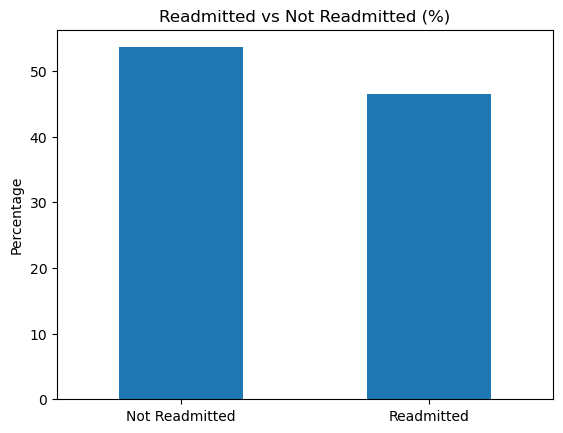

In [16]:
#visualizing readmissions versus no readmissions
readmission_pct.plot(kind="bar")

plt.title("Readmitted vs Not Readmitted (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [17]:
#viewing the readmission count by gender
df.groupby("gender")["readmitted"].value_counts()

gender  readmitted
Female  NO            28257
        >30           19257
        <30            6061
Male    NO            25059
        >30           15750
        <30            5108
Name: count, dtype: int64

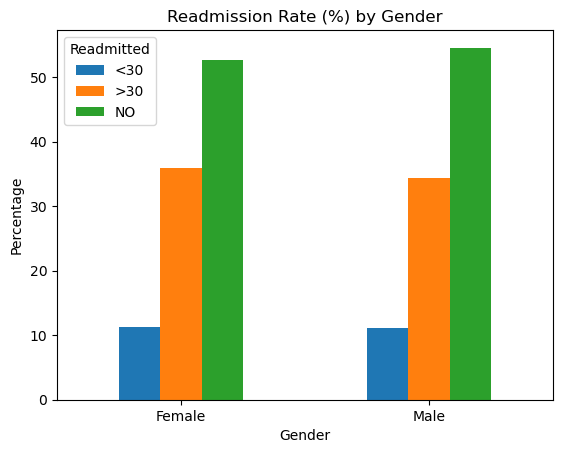

In [18]:
#visualizing readmission rates by gender inclusive of non-admission
counts = df.groupby("gender")["readmitted"].value_counts().unstack()

rates = counts.div(counts.sum(axis=1), axis=0) * 100

rates.plot(kind="bar", stacked=False)

plt.title("Readmission Rate (%) by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.legend(title="Readmitted")
plt.xticks(rotation=0)
plt.show()

#this chart shows that overall there is a similar rate of readmission and non-readmission between the females and males

In [19]:
#obtaining average of readmissions per gender
readmission_gender_pct = (df[df["readmitted_true"] == 1]["gender"].value_counts(normalize=True) * 100)
print(readmission_gender_pct)

#Of all readmitted patients, 54.83% is female and 45.17% is male.

gender
Female    54.829349
Male      45.170651
Name: proportion, dtype: float64


In [20]:
#obtaining mean readmission rate within each gender
readmission_gender_mean = df.groupby("gender")["readmitted_true"].mean() * 100
print(readmission_gender_mean)

# 47.26% of females were readmitted and 45.43% of males were readmitted

gender
Female    47.257116
Male      45.425442
Name: readmitted_true, dtype: float64


In [21]:
#obtaining average readmission rate per race and gender
racialgroup_rates = df.groupby(["race", "gender"])["readmitted_true"].mean() * 100
print(racialgroup_rates)

race             gender
AfricanAmerican  Female    46.060709
                 Male      45.268645
Asian            Female    35.534591
                 Male      34.984520
Caucasian        Female    47.993147
                 Male      45.778632
Hispanic         Female    41.575092
                 Male      42.328042
Other            Female    40.240642
                 Male      38.309115
Name: readmitted_true, dtype: float64


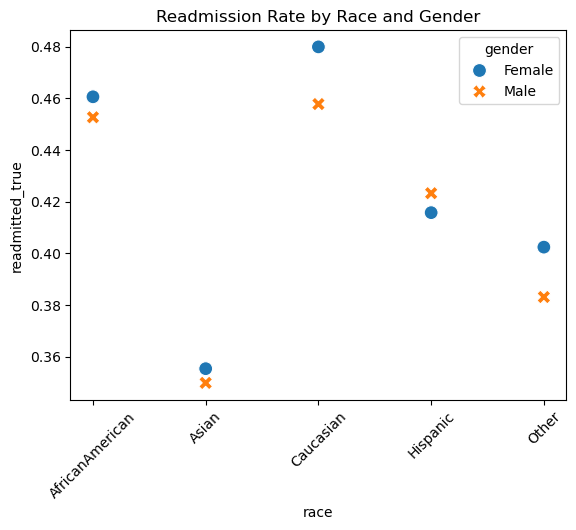

In [22]:
racial_gender_rates = df.groupby(["race", "gender"])["readmitted_true"].mean().reset_index()

sns.scatterplot(
    data=racial_gender_rates,
    x="race",
    y="readmitted_true",
    hue="gender",
    style="gender",
    s=100
)

plt.title("Readmission Rate by Race and Gender")
plt.xticks(rotation=45)
plt.show()


#this shows that of those readmitted, the highest percentage of readmissions amongst both female and male patients were Caucasian
#the smallest racial group in the dataset were Asians and display as such as such in this chart
#Hispanic males were the only ones to have a higher readmission rate than females
#in all other racial groups, females had a higher readmission rate